# Modelo final — HGB sobre el precio de Airbnb Nueva York (Fases 9 y 10)

Este notebook es el análogo de `Modelo_final.ipynb` (CatBoost) para **HistGradientBoosting**. Reentrena el modelo
elegido en `Modelado .ipynb` con **todo el train**, lo evalúa **una sola vez** en el test, analiza dónde acierta y
dónde falla, lo interpreta y lo guarda para usarlo. El plan, con las alternativas descartadas, está en
`docs/plan_modelo_final.md`; cada decisión, en `docs/bitacora_decisiones.md`.

**Por qué HGB y no CatBoost (bitácora, 10-02):** CatBoost ajustado gana a HGB ajustado en 5 de 5 folds, pero por
0,003 en RMSE en log (menos que la sd entre folds, ~0,008) y cuesta unas 16 veces más de cómputo. Se elige HGB por
parsimonia: es una **excepción declarada** a la regla del 09-30 (menor RMSE de validación), tomada después de ver la
tabla de CV. CatBoost no aparece en este notebook.

**Decisiones cerradas antes de abrir el test:**

- **Modelo (F1 = A):** solo `HGB_ajustado` (escenario B). No hay contrastes en el test; lineal, RF y la referencia
  N0.3 se comparan **con la CV** (`outputs/experimentos.csv`).
- **Intervalo (F3 + F7):** cuantiles 0,1 y 0,9 de HGB (`loss='quantile'`) con los mismos hiperparámetros que
  `HGB_ajustado`, calibrados con **CQR con un solo conjunto de calibración** (AUD-001): se ajustan con el train del
  fold 0 y se calibran con su validación; esos mismos dos modelos son los cuantiles finales.
- **Interpretación (F4):** importancia por permutación y PDP + ICE (sin SHAP: no se instala `shap`).
- **Escenario A (F5):** solo en la CV.
- **Guardado (F6):** modelo, cuantiles, correcciones, ficha y `predecir_precio`, con sufijo `_hgb` para no pisar
  los archivos del modelo CatBoost.

**Regla del test:** se carga **una vez** (sección 4). Nada de lo que salga en él puede cambiar el modelo, los
hiperparámetros ni las variables.

In [1]:
import json
import sys
from pathlib import Path
from time import perf_counter

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

sys.path.insert(0, str(Path.cwd().parent / 'scripts'))
from func_modelado import *
from func_final import *

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / 'data'
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
MODELS_DIR = PROJECT_ROOT / 'models'
MODELS_DIR.mkdir(exist_ok=True)
RUTA_REGISTRO = OUTPUT_DIR / 'experimentos.csv'

COLOR_BASE, COLOR_SECUNDARIO = '#2a6f97', '#9aa5b1'
MODELO_ELEGIDO = 'HGB_ajustado'
SUFIJO = '_hgb'   # los archivos guardados no pisan los de CatBoost
pd.set_option('display.max_columns', 40)

## 1. CARGA DEL TRAIN Y CONFIGURACIÓN DEL MODELO ELEGIDO

Los hiperparámetros y las variables se leen del registro de experimentos, no se copian a mano. Se comprueba
también el MD5 del test **sin cargarlo**: si no coincide con el de `particion.json`, se para.

In [2]:
train, bloques = cargar_modelado('train')
HIPERPARAMETROS = hiperparametros_hgb_registrados(MODELO_ELEGIDO, RUTA_REGISTRO)
COLUMNAS = columnas_registradas(MODELO_ELEGIDO, RUTA_REGISTRO)
# Mismo conjunto que el escenario B; el orden es el del registro (con max_features el orden de columnas importa)
assert set(COLUMNAS) == set(columnas_de(bloques, BLOQUES_ESCENARIO['B'])), 'Las variables del registro no son las del escenario B'

particion = json.loads((DATA_DIR / 'particion' / 'particion.json').read_text(encoding='utf-8'))
md5_test = md5_fichero(DATA_DIR / 'particion' / 'listings_test.csv')
assert md5_test == particion['md5']['test'], 'El test no coincide con la particion guardada: se para'

print(f"Train de modelado: {len(train):,} anuncios de {train[COL_GRUPO].nunique():,} anfitriones | {len(COLUMNAS)} variables")
print(f"MD5 del test (sin cargarlo): {md5_test} -> coincide con particion.json")
display(pd.Series(HIPERPARAMETROS, name='valor').to_frame())

folds = cargar_folds(train, OUTPUT_DIR / 'folds_cv.csv', 3)
FOLDS_MODELOS = [f for f in folds if f.repeticion == 0]
cv_elegido = leer_experimento(MODELO_ELEGIDO, RUTA_REGISTRO, FOLDS_MODELOS)
METRICAS_CV = {c: float(cv_elegido[c].mean()) for c in
               ['rmse_log_val', 'mae_log_val', 'r2_log_val', 'mae_usd_val', 'medae_usd_val', 'mape_val']}
METRICAS_CV_SD = {c: float(cv_elegido[c].std()) for c in METRICAS_CV}
display(pd.DataFrame({'media_cv': METRICAS_CV, 'sd_folds': METRICAS_CV_SD}).round(4))

Train de modelado: 29,538 anuncios de 21,368 anfitriones | 79 variables
MD5 del test (sin cargarlo): 6efbad2d0dd977cb41d7feb0ee114f38 -> coincide con particion.json


,valor
categorical_features,from_dtype
early_stopping,False
interaction_cst,None
l2_regularization,0.102498
learning_rate,0.022517
max_bins,255
max_depth,None
max_features,0.495053
max_iter,1448
max_leaf_nodes,15


,media_cv,sd_folds
rmse_log_val,0.4191,0.0099
mae_log_val,0.3065,0.0069
r2_log_val,0.6527,0.0130
mae_usd_val,48.1328,2.5765
medae_usd_val,21.4772,0.4252
mape_val,0.3165,0.0103


### Comparación en CV (sin test)

Con F1 = A, el test solo mide al elegido. Cuánto mejora sobre el lineal, sobre el Random Forest y sobre la referencia ingenua se
cuenta con los 5 folds guardados, que son los mismos para todos (comparación pareada).

In [3]:
registro = pd.read_csv(RUTA_REGISTRO)
registro = registro[(registro['escenario'] == 'B') & (registro['repeticion'] == 0)]
mejor_lineal = registro[registro['experimento'].str.startswith(('L4_', 'L5_'))].groupby('experimento')[
    'rmse_log_val'].mean().idxmin()
COMPARADOS = {'HGB (elegido)': MODELO_ELEGIDO, 'RF ajustado': 'RF_ajustado',
              f'Lineal ({mejor_lineal})': mejor_lineal, 'Referencia N0.3': 'N0.3_mediana_room_type_capacidad'}
por_fold = registro[registro['experimento'].isin(COMPARADOS.values())].pivot(
    index='fold', columns='experimento', values='rmse_log_val')
filas = []
for etiqueta, nombre in COMPARADOS.items():
    dif = por_fold[nombre] - por_fold[MODELO_ELEGIDO]
    filas.append({'modelo': etiqueta, 'rmse_log_cv': por_fold[nombre].mean(), 'sd_folds': por_fold[nombre].std(),
                  'dif_vs_hgb': dif.mean(), 'folds_peor_que_hgb': f'{(dif > 0).sum()}/{len(dif)}'})
tabla_cv = pd.DataFrame(filas).set_index('modelo')
display(tabla_cv.round(4))

,rmse_log_cv,sd_folds,dif_vs_hgb,folds_peor_que_hgb
modelo,,,,
HGB (elegido),0.4191,0.0099,0.0000,0/5
RF ajustado,0.4278,0.0119,0.0087,5/5
Lineal (L5_ElasticNet_alpha_0.00032),0.4329,0.0086,0.0138,5/5
Referencia N0.3,0.5349,0.0093,0.1158,5/5


#### Conclusiones:

- A rellenar tras ejecutar: **HGB** frente a **RF**, **lineal** y **N0.3** en RMSE en log (CV) y en %.
- Recordar que las diferencias se cuentan con los 5 folds, que comparten train: p-valores y «folds que mejoran» son
  orientativos, no contrastes independientes.

## 2. REENTRENAMIENTO CON TODO EL TRAIN

Se ajusta el elegido sobre todos los anuncios del train (RMSE en log). El RMSE en train debe quedar por debajo
del de validación, pero del mismo orden. Los cuantiles se ajustan en la sección 2.1.

In [4]:
X_train, y_train = train[COLUMNAS], train[TARGET]

inicio = perf_counter()
modelo_final = construir_hgb_final(COLUMNAS, HIPERPARAMETROS).fit(X_train, y_train)
t_ajuste = perf_counter() - inicio

rmse_train = metricas(y_train, modelo_final.predict(X_train))['rmse_log_val']
print(f"Ajuste del elegido: {t_ajuste:.0f} s | RMSE en train {rmse_train:.4f} | "
      f"RMSE en validacion (CV) {METRICAS_CV['rmse_log_val']:.4f}")
assert descripcion_modelo(modelo_final) == descripcion_registrada(MODELO_ELEGIDO, RUTA_REGISTRO), \
    'El modelo no es el del registro'

Ajuste del elegido: 9 s | RMSE en train 0.3631 | RMSE en validacion (CV) 0.4191


### 2.1 Calibración CQR del intervalo

El intervalo 10 %-90 % de HGB cubría el 72,8 % en la CV (nominal 80 %). La regresión cuantílica conformal
(Romano et al., 2019) mide cuánto se quedan cortos los cuantiles en datos que no han visto y los ensancha lo justo.

**Un solo conjunto de calibración (AUD-001):** los cuantiles se ajustan con el train del fold 0 (80 %) y se
calibran con su validación (anfitriones distintos, ~20 %). Esos mismos dos modelos son los cuantiles finales.
Frente a calibrar con los 5 folds (10 ajustes más) cuesta 2 ajustes en lugar de 12 y su cobertura es exacta en
muestra finita si calibración y datos nuevos son intercambiables.

**Limitaciones que se declaran:** los cuantiles ven el 80 % del train, no todo; y la intercambiabilidad se
cumple solo de forma aproximada (los anuncios de un anfitrión están correlacionados y el test se separó por
anfitrión, como la validación del fold).

In [5]:
f0 = FOLDS_MODELOS[0]
X_ent, y_ent = X_train.iloc[f0.train], y_train.iloc[f0.train]
X_cal, y_cal = X_train.iloc[f0.validacion], y_train.iloc[f0.validacion].to_numpy()

cuantiles = {alfa: construir_hgb_final(COLUMNAS, HIPERPARAMETROS, cuantil=alfa).fit(X_ent, y_ent)
             for alfa in (CUANTIL_BAJO, CUANTIL_ALTO)}
cal_bajo, cal_alto = (cuantiles[a].predict(X_cal) for a in (CUANTIL_BAJO, CUANTIL_ALTO))

cobertura_sin = cobertura_intervalo(y_cal, cal_bajo, cal_alto)
CORRECCION_CQR = calibrar_cqr(cal_bajo, cal_alto, y_cal)
cobertura_con = cobertura_intervalo(y_cal, cal_bajo - CORRECCION_CQR, cal_alto + CORRECCION_CQR)
print(f"Calibracion con {len(y_cal):,} anuncios (fold 0, anfitriones distintos a los del ajuste)")
print(f"Cobertura en el conjunto de calibracion: sin calibrar {cobertura_sin:.1%} | con CQR {cobertura_con:.1%} "
      f"(nominal {COBERTURA_NOMINAL:.0%}; con CQR es 80% por construccion)")
print(f"Correccion: {CORRECCION_CQR:+.4f} en log (cada extremo se mueve un {np.expm1(abs(CORRECCION_CQR)):.1%})")

Calibracion con 5,907 anuncios (fold 0, anfitriones distintos a los del ajuste)
Cobertura en el conjunto de calibracion: sin calibrar 72.9% | con CQR 80.0% (nominal 80%; con CQR es 80% por construccion)
Correccion: +0.0657 en log (cada extremo se mueve un 6.8%)


#### Conclusiones:

- A rellenar tras ejecutar: tiempo de ajuste, RMSE en train frente a CV y **cobertura** sin calibrar y con CQR.

## 3. GUARDADO DEL MODELO

`joblib` del pipeline del modelo final y de los cuantiles (ajustados con el 80 % del train), más la corrección CQR.
HGB no tiene formato de guardado propio, así que `joblib` es el único: carga solo con la misma versión de
scikit-learn (queda anotada en la ficha). La ficha con las métricas del test se escribe después de la sección 4.

In [6]:
joblib.dump(modelo_final, MODELS_DIR / f'modelo_final{SUFIJO}.joblib')
joblib.dump({'cuantiles': cuantiles, 'correccion_cqr': CORRECCION_CQR}, MODELS_DIR / f'cuantiles{SUFIJO}.joblib')
print({p.name: f'{p.stat().st_size / 1e6:.1f} MB' for p in sorted(MODELS_DIR.iterdir()) if p.stem.endswith(SUFIJO)})

{'cuantiles_hgb.joblib': '5.8 MB', 'modelo_final_hgb.joblib': '2.9 MB'}


## 4. EVALUACIÓN EN EL TEST (ÚNICA)

**Esta es la única celda del notebook que carga el test.** Las métricas son las mismas que en la CV
(`metricas`), con intervalo de confianza al 95 % por *bootstrap* remuestreando **anfitriones** (2.000 réplicas),
porque los anuncios de un mismo anfitrión no son independientes.

In [7]:
test, _ = cargar_modelado('test')
assert set(test[COL_GRUPO]).isdisjoint(set(train[COL_GRUPO])), 'Anfitriones del test en el train'
X_test, y_test = test[COLUMNAS], test[TARGET].to_numpy()
pred_test = modelo_final.predict(X_test)
anfitriones_test = test[COL_GRUPO].to_numpy()

METRICAS_TEST = metricas(y_test, pred_test)
replicas_todas = bootstrap_por_anfitrion(y_test, pred_test, anfitriones_test, metricas)   # una pasada, 6 metricas
filas = []
for nombre in METRICAS_CV:
    ic = resumen_bootstrap(replicas_todas[nombre].to_numpy(), METRICAS_TEST[nombre])
    filas.append({'metrica': nombre, 'test': ic['valor'], 'ic95_bajo': ic['ic95_bajo'], 'ic95_alto': ic['ic95_alto'],
                  'cv_media': METRICAS_CV[nombre], 'cv_sd': METRICAS_CV_SD[nombre],
                  'dentro_de_cv_2sd': abs(ic['valor'] - METRICAS_CV[nombre]) <= 2 * METRICAS_CV_SD[nombre]})
tabla_test = pd.DataFrame(filas).set_index('metrica')
print(f"Test: {len(test):,} anuncios de {test[COL_GRUPO].nunique():,} anfitriones")
display(tabla_test.round(4))
tabla_test.to_csv(OUTPUT_DIR / f'resultados_test{SUFIJO}.csv')

Test: 7,384 anuncios de 5,336 anfitriones


,test,ic95_bajo,ic95_alto,cv_media,cv_sd,dentro_de_cv_2sd
metrica,,,,,,
rmse_log_val,0.4239,0.4067,0.4416,0.4191,0.0099,True
mae_log_val,0.3058,0.2941,0.3184,0.3065,0.0069,True
r2_log_val,0.6449,0.6083,0.6799,0.6527,0.0130,True
mae_usd_val,49.3989,44.6763,55.0036,48.1328,2.5765,True
medae_usd_val,21.1165,19.4157,23.9694,21.4772,0.4252,True
mape_val,0.3086,0.2981,0.3201,0.3165,0.0103,True


### 4.1 Frente a la literatura

R² en log del test frente al del paper de referencia (`docs/Referencias/1907.12665v1.pdf`). **La cifra del
paper está pendiente de verificar** en el PDF antes de citarla. El paper usa partición aleatoria por anuncio y
reseñas como variable, así que no es comparable de forma directa: aquí la partición es por anfitrión y no se
usan reseñas.

#### Conclusiones:

- A rellenar tras ejecutar: **RMSE en log**, **MAE en dólares** y **R²** del test con su IC al 95 %.
- Si el test sale fuera de CV ± 2 sd: discutir sobreajuste de la búsqueda de hiperparámetros frente a diferencia
  de composición entre train y test.
- Mejora sobre el lineal, RF y N0.3 **con los números de la CV** (tabla de la sección 1), no con el test.

## 5. INTERVALO DE PRECIO EN EL TEST

Cobertura real del intervalo 10 %-90 %, sin calibrar y con CQR, global y por segmento. Anchura mediana en dólares.

In [8]:
bajo_test = cuantiles[CUANTIL_BAJO].predict(X_test)
alto_test = cuantiles[CUANTIL_ALTO].predict(X_test)
intervalos = {'sin calibrar': (bajo_test, alto_test),
              'CQR': (bajo_test - CORRECCION_CQR, alto_test + CORRECCION_CQR)}

filas = []
for nombre, (b, a) in intervalos.items():
    replicas = bootstrap_por_anfitrion(y_test, np.column_stack([b, a]), anfitriones_test,
                                       lambda y, p: {'cobertura': cobertura_intervalo(y, p[:, 0], p[:, 1])})
    ic = resumen_bootstrap(replicas['cobertura'].to_numpy(), cobertura_intervalo(y_test, b, a))
    filas.append({'intervalo': nombre, 'cobertura': ic['valor'], 'ic95_bajo': ic['ic95_bajo'],
                  'ic95_alto': ic['ic95_alto'], 'anchura_mediana_usd': np.median(np.exp(a) - np.exp(b))})
display(pd.DataFrame(filas).set_index('intervalo').round(3))

test['cubierto_cqr'] = (y_test >= intervalos['CQR'][0]) & (y_test <= intervalos['CQR'][1])
test['anchura_cqr_usd'] = np.exp(intervalos['CQR'][1]) - np.exp(intervalos['CQR'][0])
test['quintil_precio'] = pd.qcut(test['price'], 5, labels=['Q1 (barato)', 'Q2', 'Q3', 'Q4', 'Q5 (caro)'])
for columna in ['room_type', 'district', 'quintil_precio']:
    tabla = test.groupby(columna, observed=True).agg(n=('cubierto_cqr', 'size'), cobertura_cqr=('cubierto_cqr', 'mean'),
                                                    anchura_mediana_usd=('anchura_cqr_usd', 'median'))
    display(tabla[tabla['n'] >= 30].round(3))

,cobertura,ic95_bajo,ic95_alto,anchura_mediana_usd
intervalo,,,,
sin calibrar,0.721,0.670,0.754,79.101
CQR,0.790,0.739,0.824,93.000


,n,cobertura_cqr,anchura_mediana_usd
room_type,,,
Entire place,3877,0.774,138.447
Hotel room,57,0.614,153.387
Private room,3315,0.814,61.011
Shared room,135,0.756,71.673


,n,cobertura_cqr,anchura_mediana_usd
district,,,
Bronx,198,0.823,69.207
Brooklyn,2889,0.819,81.628
Manhattan,3294,0.754,120.475
Queens,945,0.829,65.168
Staten Island,58,0.638,70.151


,n,cobertura_cqr,anchura_mediana_usd
quintil_precio,,,
Q1 (barato),1547,0.769,51.743
Q2,1432,0.853,72.277
Q3,1601,0.875,98.344
Q4,1339,0.881,132.771
Q5 (caro),1465,0.575,186.948


#### Conclusiones:

- A rellenar tras ejecutar: cobertura global con CQR (objetivo 80 %), y en qué segmentos se queda corta o larga.
- El quintil de precio condiciona sobre el resultado (el intervalo falla más en los extremos): se interpreta como
  descripción, no como contraste.

## 6. ANÁLISIS DE ERRORES

Toda tabla lleva su `n`, y las celdas con N < 30 se enmascaran (H-014).

In [9]:
test['pred_usd'] = np.exp(pred_test)
test['error_abs_usd'] = (test['price'] - test['pred_usd']).abs()
test['capacidad'] = pd.cut(test['accommodates'], [0, 1, 2, 4, 6, 100], labels=['1', '2', '3-4', '5-6', '7+'])
for columnas in (['room_type'], ['district'], ['capacidad'], ['quintil_precio']):
    display(error_por_segmento(test, pred_test, columnas).round(3))

,n,mae_usd,mediana_usd,mape
room_type,,,,
Entire place,3877,69.266,34.343,0.317
Hotel room,57,168.689,68.948,0.611
Private room,3315,24.903,13.286,0.289
Shared room,135,29.987,13.142,0.422


,n,mae_usd,mediana_usd,mape
district,,,,
Bronx,198,34.889,14.374,0.326
Brooklyn,2889,39.376,17.906,0.297
Manhattan,3294,64.513,29.701,0.326
Queens,945,30.720,13.019,0.280
Staten Island,58,44.120,19.586,0.344


,n,mae_usd,mediana_usd,mape
capacidad,,,,
1,1155,25.588,11.943,0.291
2,3587,37.132,18.854,0.297
3-4,1778,56.603,29.585,0.307
5-6,627,93.576,41.530,0.353
7+,237,180.183,71.441,0.468


,n,mae_usd,mediana_usd,mape
quintil_precio,,,,
Q1 (barato),1547,15.055,11.140,0.387
Q2,1432,20.080,13.942,0.287
Q3,1601,26.985,20.230,0.267
Q4,1339,35.770,28.738,0.241
Q5 (caro),1465,151.275,83.656,0.354


In [10]:
peores = test.nlargest(20, 'error_abs_usd')[['listing_id', 'room_type', 'district', 'accommodates', 'bedrooms',
                                             'price', 'pred_usd', 'error_abs_usd']]
display(peores.round(1))

,listing_id,room_type,district,accommodates,bedrooms,price,pred_usd,error_abs_usd
135,2271504,Entire place,Brooklyn,7,3.0,6500,384.0,6116.0
119,2243699,Entire place,Manhattan,16,5.0,5250,1015.8,4234.2
1942,41583926,Entire place,Manhattan,2,5.0,4167,282.3,3884.7
389,30589636,Entire place,Manhattan,4,2.0,3200,141.8,3058.2
1391,40918843,Entire place,Manhattan,1,1.0,2850,144.7,2705.3
323,13963005,Entire place,Queens,6,2.0,2350,145.6,2204.4
2209,42528852,Entire place,Brooklyn,16,3.0,2526,360.8,2165.2
2326,6833395,Entire place,Manhattan,2,1.0,2000,185.4,1814.6
630,23855466,Entire place,Manhattan,2,1.0,2000,196.1,1803.9
82,26496505,Entire place,Queens,2,1.0,1800,91.4,1708.6


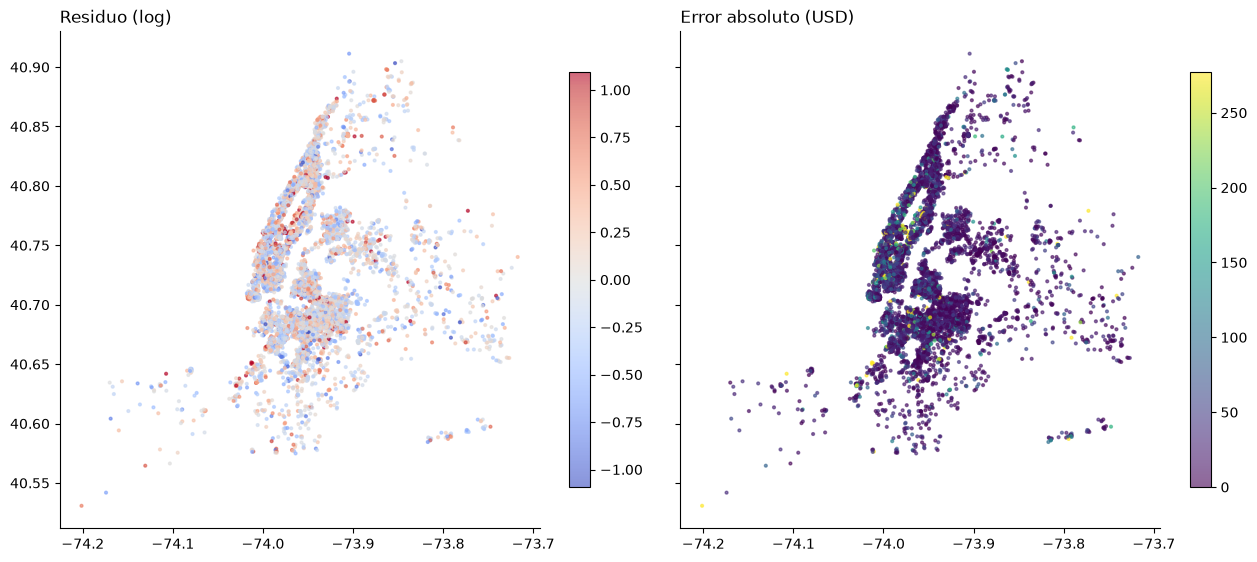

In [11]:
fig, ejes = plt.subplots(1, 2, figsize=(13, 5.5), sharex=True, sharey=True)
residuo = y_test - pred_test
for eje, (titulo, serie, mapa) in zip(ejes, [('Residuo (log)', residuo, 'coolwarm'),
                                             ('Error absoluto (USD)', test['error_abs_usd'], 'viridis')]):
    limite = np.percentile(np.abs(serie), 98)
    grafico = eje.scatter(test['longitude'], test['latitude'], c=serie, s=4, alpha=0.6, cmap=mapa,
                          vmin=-limite if mapa == 'coolwarm' else 0, vmax=limite)
    eje.set_title(titulo, loc='left')
    eje.set_aspect(1 / np.cos(np.radians(40.7)))
    eje.spines[['top', 'right']].set_visible(False)
    plt.colorbar(grafico, ax=eje, shrink=0.8)
plt.tight_layout()
plt.show()

In [12]:
# Sensibilidad a la regla de exclusion (H-024): metricas sin los precios por encima del P99 global del TRAIN
# (el corte no usa el test) frente a la regla de bloqueo ya aplicada en el dataset.
corte_p99 = train['price'].quantile(0.99)
sin_p99 = (test['price'] <= corte_p99).to_numpy()
filas = {'regla de bloqueo (la usada)': metricas(y_test, pred_test),
         f'sin P99 global (>{corte_p99:.0f} USD)': metricas(y_test[sin_p99], pred_test[sin_p99])}
display(pd.DataFrame(filas).T.round(4).assign(n=[len(test), int(sin_p99.sum())]))

,rmse_log_val,mae_log_val,r2_log_val,mae_usd_val,medae_usd_val,mape_val,n
regla de bloqueo (la usada),0.4239,0.3058,0.6449,49.3989,21.1165,0.3086,7384
sin P99 global (>794 USD),0.3889,0.2929,0.6572,38.4948,20.8433,0.3042,7303


#### Conclusiones:

- A rellenar tras ejecutar: segmentos con mayor **MAE** y **MAPE**, si quedan **manchas espaciales** en el mapa
  de residuos, qué tienen en común los 20 peores errores y cuánto cambian las métricas con la regla del P99 (H-024).

## 7. INTERPRETACIÓN

Permutación en el test y PDP + ICE (sin SHAP). Los tres anuncios que se describen por separado se eligen con una
regla fijada aquí, antes de mirar su predicción: el de error más cercano a la mediana, el anuncio del 5 % más caro
mejor predicho y el peor error de la sección 6. De ellos se muestra el valor de las variables más importantes, el
precio real, el predicho y su intervalo, no una descomposición aditiva.

In [13]:
grupos_bloque = {b: [c for c in cols if c in COLUMNAS] for b, cols in bloques.items()}
grupos_bloque = {b: c for b, c in grupos_bloque.items() if c}
grupos_variable = {c: [c] for c in COLUMNAS if c not in ('latitude', 'longitude')}
grupos_variable['latitude + longitude'] = ['latitude', 'longitude']

imp_bloques = importancia_permutacion(modelo_final, X_test, test[TARGET], grupos_bloque)
imp_variables = importancia_permutacion(modelo_final, X_test, test[TARGET], grupos_variable)

def resumen_importancia(tabla):
    return tabla.groupby('grupo')['aumento_rmse'].agg(['mean', 'std']).sort_values('mean', ascending=False)

display(resumen_importancia(imp_bloques).round(4))
display(resumen_importancia(imp_variables).head(15).round(4))

,mean,std
grupo,,
B0_producto,0.2977,0.0040
B1_ubicacion,0.1086,0.0022
B2b_anfitrion,0.0497,0.0020
B3_amenities_comunes,0.0464,0.0013
B2a_condiciones,0.0045,0.0004


,mean,std
grupo,,
accommodates,0.0481,0.0022
property_type_grp,0.0468,0.0002
room_type,0.0322,0.0013
bedrooms,0.0239,0.0009
neighbourhood,0.0231,0.0014
latitude + longitude,0.0204,0.0012
host_total_listings_count,0.0094,0.0004
host_response_rate,0.0071,0.0008
dist_centro_km,0.0063,0.0008


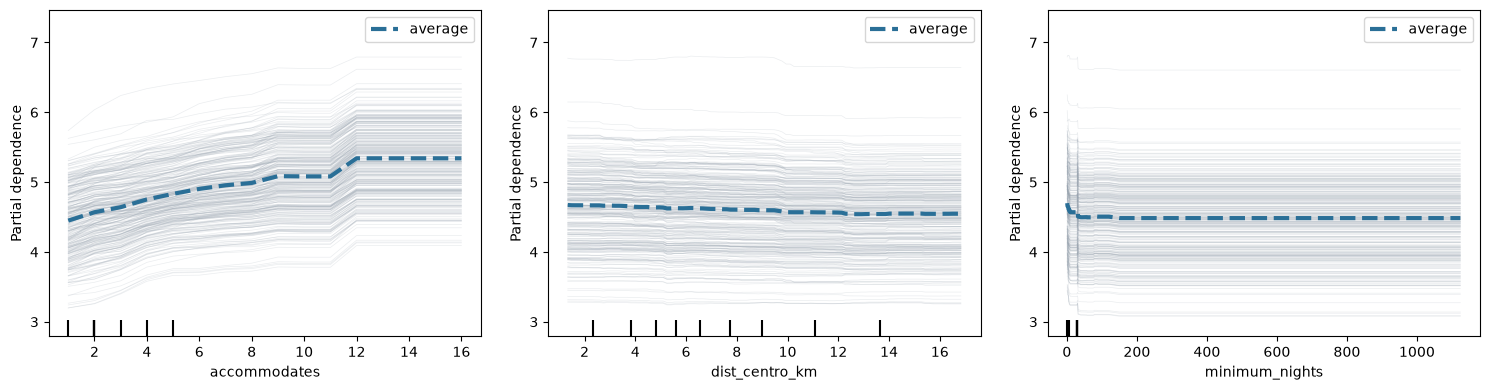

In [14]:
from sklearn.inspection import PartialDependenceDisplay

VARIABLES_PDP = ['accommodates', 'dist_centro_km', 'minimum_nights']
X_pdp = X_test.astype({c: float for c in VARIABLES_PDP})   # sklearn no admite PDP sobre enteros

fig, ejes = plt.subplots(1, 3, figsize=(15, 4))
PartialDependenceDisplay.from_estimator(modelo_final, X_pdp, VARIABLES_PDP,
                                        kind='both', subsample=300, random_state=SEMILLA, ax=ejes,
                                        ice_lines_kw={'color': COLOR_SECUNDARIO, 'alpha': 0.2},
                                        pd_line_kw={'color': COLOR_BASE, 'lw': 3})
plt.tight_layout()
plt.show()

In [15]:
error_mediano = test['error_abs_usd'].median()
tipico = (test['error_abs_usd'] - error_mediano).abs().idxmin()
caros = test[test['price'] >= test['price'].quantile(0.95)]
caro_bien = (caros['error_abs_usd'] / caros['price']).idxmin()
peor = test['error_abs_usd'].idxmax()

# Variables mas importantes por permutacion (las de latitude + longitude se muestran por separado)
top = resumen_importancia(imp_variables).head(8).index
columnas_top = [c for grupo in top for c in grupos_variable[grupo]]

filas = []
for etiqueta, i in {'tipico': tipico, 'caro bien predicho': caro_bien, 'peor error': peor}.items():
    pos = test.index.get_loc(i)
    filas.append({'anuncio': etiqueta, 'listing_id': test.loc[i, 'listing_id'], 'precio_real': test.loc[i, 'price'],
                  'precio_predicho': test.loc[i, 'pred_usd'], 'intervalo_bajo': np.exp(intervalos['CQR'][0][pos]),
                  'intervalo_alto': np.exp(intervalos['CQR'][1][pos]), **X_test.loc[i, columnas_top].to_dict()})
display(pd.DataFrame(filas).set_index('anuncio').T)

anuncio,tipico,caro bien predicho,peor error
listing_id,2584258,273190,2271504
precio_real,28,900,6500
precio_predicho,49.100816,905.1438,384.002149
intervalo_bajo,32.250827,278.489894,146.436229
intervalo_alto,76.626387,1250.488331,893.682988
accommodates,2,12,7
property_type_grp,Private room in apartment,Entire house,Entire apartment
room_type,Private room,Entire place,Entire place
bedrooms,1.0,6.0,3.0
neighbourhood,Bushwick,West Village,Clinton Hill


#### Conclusiones:

- A rellenar tras ejecutar: orden de importancia en el test frente al de la CV (¿se mantiene?) y forma de las
  curvas PDP de `accommodates`, `dist_centro_km` y `minimum_nights`.
- Contraste con el lineal: dónde coinciden los coeficientes hedónicos con la importancia por permutación y dónde
  aparecen no linealidades o interacciones en las curvas ICE.
- La permutación y las PDP describen cómo usa las variables el **modelo**, no una relación causal con el precio.
  Con variables correlacionadas (p. ej. `accommodates` y `bedrooms`) la importancia de cada una se reparte.

## 8. USO DEL MODELO GUARDADO

Se carga todo desde disco y se predice un anuncio **en bruto** (filas de `listings.csv`). La cadena es
anuncio en bruto → preparador → modelo → `exp(ŷ)`.

**Aviso:** `n_anuncios_ny` y `reputacion_cartera` se calculan sobre las filas que se pasan (decisión del 09-26).
Para un anfitrión con varios anuncios hay que pasar su cartera completa en Nueva York.

In [16]:
from preparacion_datos import PreparadorListings, RUTA_PREPARADOR, cargar_listings_ny

preparador = PreparadorListings.cargar(RUTA_PREPARADOR)
modelo_cargado = joblib.load(MODELS_DIR / f'modelo_final{SUFIJO}.joblib')
guardado = joblib.load(MODELS_DIR / f'cuantiles{SUFIJO}.joblib')

brutos = cargar_listings_ny(DATA_DIR / 'listings.csv')
anfitrion = train.loc[train['n_anuncios_ny'].between(2, 3), COL_GRUPO].iloc[0]
cartera = brutos[brutos['host_id'] == anfitrion]

resultado = predecir_precio(cartera, preparador, modelo_cargado, guardado['cuantiles'], guardado['correccion_cqr'],
                            COLUMNAS)
real = cartera.set_index('listing_id')['price'].reindex(resultado['listing_id']).to_numpy()
display(resultado.assign(precio_real=real).round(1))

en_train = resultado[resultado['listing_id'].isin(train['listing_id'])]   # los excluidos del dataset no estan
en_memoria = modelo_final.predict(train.set_index('listing_id').loc[en_train['listing_id'], COLUMNAS])
assert np.allclose(np.exp(en_memoria), en_train['precio_mediano'], rtol=1e-6), 'El modelo cargado predice distinto'
print('El modelo guardado predice igual que el de memoria')

,listing_id,precio_mediano,precio_bajo,precio_alto,precio_real
0,39487508,139.6,84.4,235.0,119
1,43162879,60.0,32.6,96.4,44
2,43163345,58.0,32.5,95.8,44


El modelo guardado predice igual que el de memoria


In [17]:
ficha = ficha_modelo(HIPERPARAMETROS, COLUMNAS, {'media': METRICAS_CV, 'sd': METRICAS_CV_SD},
                     {k: float(v) for k, v in METRICAS_TEST.items()}, CORRECCION_CQR,
                     particion['md5']['train'], particion['md5']['test'],
                     descripcion=DESCRIPCION_HGB, librerias=('scikit-learn', 'pandas', 'numpy'))
guardar_ficha(ficha, MODELS_DIR / f'ficha_modelo{SUFIJO}.json')
print(json.dumps(ficha['versiones'], indent=1))

{
 "python": "3.13.14",
 "scikit-learn": "1.9.0",
 "pandas": "3.0.5",
 "numpy": "2.5.1"
}


## 9. CONCLUSIONES Y RECOMENDACIONES

**Para el analista:** resultado en el test con su intervalo, comparación con la CV, qué funciona y dónde falla.

**Para el sponsor:** «un anuncio nuevo se predice con un error típico de $X», qué influye en el precio y el rango.

**Qué estima el modelo:** `exp(ŷ)` es la **mediana** del precio, no la media. Si hiciera falta la media, *smearing*
de Duan (bitácora, 09-23).

**Limitaciones:** el perfil del anfitrión se mide en 2021, no al publicar (escenario B); los datos son de un
único momento; la CQR con CV es aproximada; la importancia por permutación y las PDP no son causales; HGB se eligió sobre CatBoost por parsimonia, con una diferencia de ~0,003 en CV. El resto, en la sección 13 de `plan_modelado.md`.

**Líneas futuras:** variables del título (D8), reseñas como complemento en un escenario C, otra ventana temporal.

#### Conclusiones:

- A rellenar tras ejecutar todo el notebook.